In [49]:
import math
import pickle

import datajoint as dj
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as plticker
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy import ndimage
import scipy
import seaborn as sns
import torch
from tqdm import tqdm
from scipy.stats import wilcoxon, ttest_ind, ttest_1samp
from statsmodels.stats.multitest import multipletests

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

from featurevis.ops import center_and_crop_image, standardize_image
from staticnet_analyses import base, gabors
from staticnet_pilots.analyses import *
from staticnet_invariance import (
    dei_stimulus_reconfigured as dei_stimulus,
    deis_reconfigured as deis_schema,
    toy,
    toy_deis,
)
from staticnet_invariance.segmentation import find_cross

stimulus = dj.create_virtual_module('stimulus', 'pipeline_stimulus')
imagenet = dj.create_virtual_module('pipeline_imagenet', 'pipeline_imagenet')
experiment = dj.create_virtual_module('pipeline_experiment', 'pipeline_experiment')
meso = dj.create_virtual_module('pipeline_meso', 'pipeline_meso')
fuse = dj.create_virtual_module('fuse', 'pipeline_fuse')
collection = dj.create_virtual_module('collection', 'pipeline_collection')

# get manually curated neuron information 
with open('/dj-stor01/users/zhiwei/closed_loop_bad_matching_neurons_by_visual_inspection_on_summary_images.pickle', 'rb') as handle:
    manual_exclude_dic = pickle.load(handle)
    
def get_exclude_neurons(manual_exclude_dic, corr_thresh=0.42, dist_thresh=10, exclude_type='confusion', mei_key=None):
    if exclude_type == 'confusion':
        manual_exclude = manual_exclude_dic['{}-{}-{}'.format(*mei_key.values())]
        neuron_dics = (DEIClosedLoopSummaryResults.Neuron() & mei_key).fetch('neuron_id', 'matched_corr', 'matched_distance', as_dict=True, order_by='neuron_id')
        exclude_cols = [i for i, dic in enumerate(neuron_dics) if (dic['neuron_id'] in manual_exclude) or (dic['matched_corr'] < corr_thresh) or (dic['matched_distance'] > dist_thresh)]
        return exclude_cols
    else:
        manual_exclude = []
        for key, val in zip(manual_exclude_dic.keys(), manual_exclude_dic.values()):
            manual_exclude.extend([dict(animal_id=key.split('-')[0], session=key.split('-')[1], scan_idx=key.split('-')[2], neuron_id=n) for n in val])

        rel1 = DEIClosedLoopSummaryResults.Neuron & 'group_id in (241)'
        rel2 = DEIClosedLoopSummaryResults.Neuron & manual_exclude
        rel3 = DEIClosedLoopSummaryResults.Neuron & 'group_id not in (241) and matched_corr < {} or matched_distance > {}'.format(corr_thresh, dist_thresh)
        rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 7 and scan_idx = 12'
        # rel4 = DEIClosedLoopSummaryResults.Neuron & 'animal_id = 27470 and session = 6 and scan_idx = 8' # accidentally showed exact same stimuli for 27470-6-8 and 27470-7-12

        return rel1.proj() + rel2.proj() + rel3.proj() + rel4.proj()

def cal_dof(x,y):
    a = x.std()**2/len(x)
    b = y.std()**2/len(y)
    return (a+b)**2 / (a**2/(len(x)-1) + b**2/(len(y)-1))

# x,y has format n_pts*n_repeats(or observations)
def get_stat(x, y, alternative='two-sided'):
    print(wilcoxon(x.mean(axis=1),y.mean(axis=1), alternative=alternative))
    print('DOF: {:.2f}'.format(np.nanmean([cal_dof(i,j) for i,j in zip(x,y)])))

    stats = np.array([ttest_ind(i,j,equal_var=False, alternative=alternative) for i,j in zip(x,y)])
    temp = stats[:,0][stats[:,1]<0.05]
    print('Prior correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(temp), len(temp)/len(x)*100, (temp<0).sum(), (temp<0).sum()/len(x)*100, (temp>0).sum(), (temp>0).sum()/len(x)*100))

    cr_temp = stats[:,0][multipletests(stats[:,1],0.05,method="fdr_bh")[0]]
    print('Post correction: Different {} {:.2f}% Less {} {:.2f}%, Greater {} {:.2f}%'.format(len(cr_temp), len(cr_temp)/len(x)*100, (cr_temp<0).sum(), (cr_temp<0).sum()/len(x)*100, (cr_temp>0).sum(), (cr_temp>0).sum()/len(x)*100))

## 2a

In [14]:
cell_rest = {}
cell_rest['toy_simple'] = dict(group_id=6, member_id=111, config_id=1, stim_params=10, diverse_params = 22, threshold_params=2, texture_params=20, score_params = 2, color='#37375e', label='Ideal simple', neuron_type='toy')
cell_rest['simple'] = dict(group_id = 272, neuron_id = 6302, stim_params = 10, diverse_params = 17, threshold_params=2, texture_params=20, score_params = 2, color='#356288', label='Simple', neuron_type='real')
cell_rest['toy_complex'] = dict(group_id=6, member_id=51, config_id=1, stim_params=10, diverse_params = 22, threshold_params=2, texture_params=20, score_params = 2, color='#cc333f', label='Ideal complex', neuron_type='toy')
cell_rest['complex'] = dict(group_id = 243, neuron_id = 1722, stim_params = 10, diverse_params = 17, threshold_params=2, texture_params=20, score_params = 2, color='#f2766e', label='Complex', neuron_type='real')
cell_rest['checkerboard'] = dict(group_id = 271, neuron_id = 628, stim_params = 10, diverse_params = 17, theshold_params=2, texture_params=20, score_params = 2, color='#ffad98', label='Checkerboard', neuron_type='real')
cell_rest['comb'] = dict(group_id = 233, neuron_id = 623, stim_params = 10, diverse_params = 14, threshold_params=2, texture_params=20, score_params = 2, color='#aacfdd', label='Comb', neuron_type='real')
cell_rest['high-low'] = dict(group_id = 237, neuron_id = 3932, stim_params = 10, diverse_params = 14, threshold_params=2, texture_params=20, score_params = 2, color='#907193', label='High-low frequency', neuron_type='real')


In [15]:
# only MEI and DEIs for all example cells
all_meis, all_masks, all_xs, all_ys, all_deis = [], [], [], [], []
n_images = 5
for key in list(cell_rest.keys()):
    rest = cell_rest[key]
    if rest['neuron_type'] == 'real':
        seed = int(1e3) + rest['neuron_id'] + rest['group_id']
        # if key == 'simple':
        #     seed = seed + 1000

        control_rest = 'experiment LIKE "dei_multi%%"'
        texture_rest = 'experiment LIKE "dei_texture_multi%%"'
        exclude = 'experiment != "dei_multi_population"'

        if len(base.MEIMask * stimulus.StaticImage.Image * stimulus.StaticImage.MaskFixedMEI & rest & control_rest & exclude) == 1:
            key, mei, mask, x, y = (base.MEIMask * stimulus.StaticImage.Image * stimulus.StaticImage.MaskFixedMEI & rest & control_rest & exclude).fetch1('KEY', 'image', 'mask', 'mask_x', 'mask_y')
            deis = (stimulus.StaticImage.Image * stimulus.StaticImage.MaskedDEI & rest & control_rest & exclude).fetch('image', order_by='group_id, neuron_id, dei_id')
        else: 
            key, mei, mask, x, y = (base.MEIMask * base.MEI * dei_stimulus.StimulusParameters & rest & dict(mei_params=10, mask_params=3, threshold_params=2)).fetch1('KEY', 'mei', 'mask', 'mask_x', 'mask_y')
            deis = (deis_schema.DEI * deis_schema.DEIGoodRun * dei_stimulus.StimulusParameters & rest & dict(mei_params=10, mask_params=3, threshold_params=2)).fetch1('deis')
            mei = dei_stimulus.prepare_stimulus(key, mei, mask)[-1]
            deis = np.stack([dei_stimulus.prepare_stimulus(key, dei, mask)[-1] for dei in deis])

    elif rest['neuron_type'] == 'toy':
        seed = 1234 + rest['member_id'] + rest['group_id']
        key, mei, mask, x, y = (toy_deis.MEIMask * toy_deis.MEI * dei_stimulus.StimulusParameters & rest & dict(mei_params=1, mask_params=3, threshold_params=2)).fetch1('KEY', 'mei', 'mask', 'mask_x', 'mask_y')
        deis = (toy_deis.DEINew * toy_deis.DEINewGoodRun * dei_stimulus.StimulusParameters & rest & dict(mei_params=1, mask_params=3, threshold_params=2)).fetch1('deis')
        mei = dei_stimulus.prepare_stimulus(key, mei, mask)[-1]
        deis = np.stack([dei_stimulus.prepare_stimulus(key, dei, mask)[-1] for dei in deis])

    deis = np.stack(deis).reshape(20, 144, 256)
    np.random.seed(seed)
    idxs = np.random.choice(np.arange(20), n_images, replace=False)
    deis = deis[idxs]

    all_meis.append(mei)
    all_masks.append(mask)
    all_xs.append(x)
    all_ys.append(y)
    all_deis.append(deis)

crosses = []
for deis in all_deis:
    cross, _ = find_cross(deis, 1)
    crosses.append(cross)


100%|██████████| 5/5 [00:07<00:00,  1.49s/it]


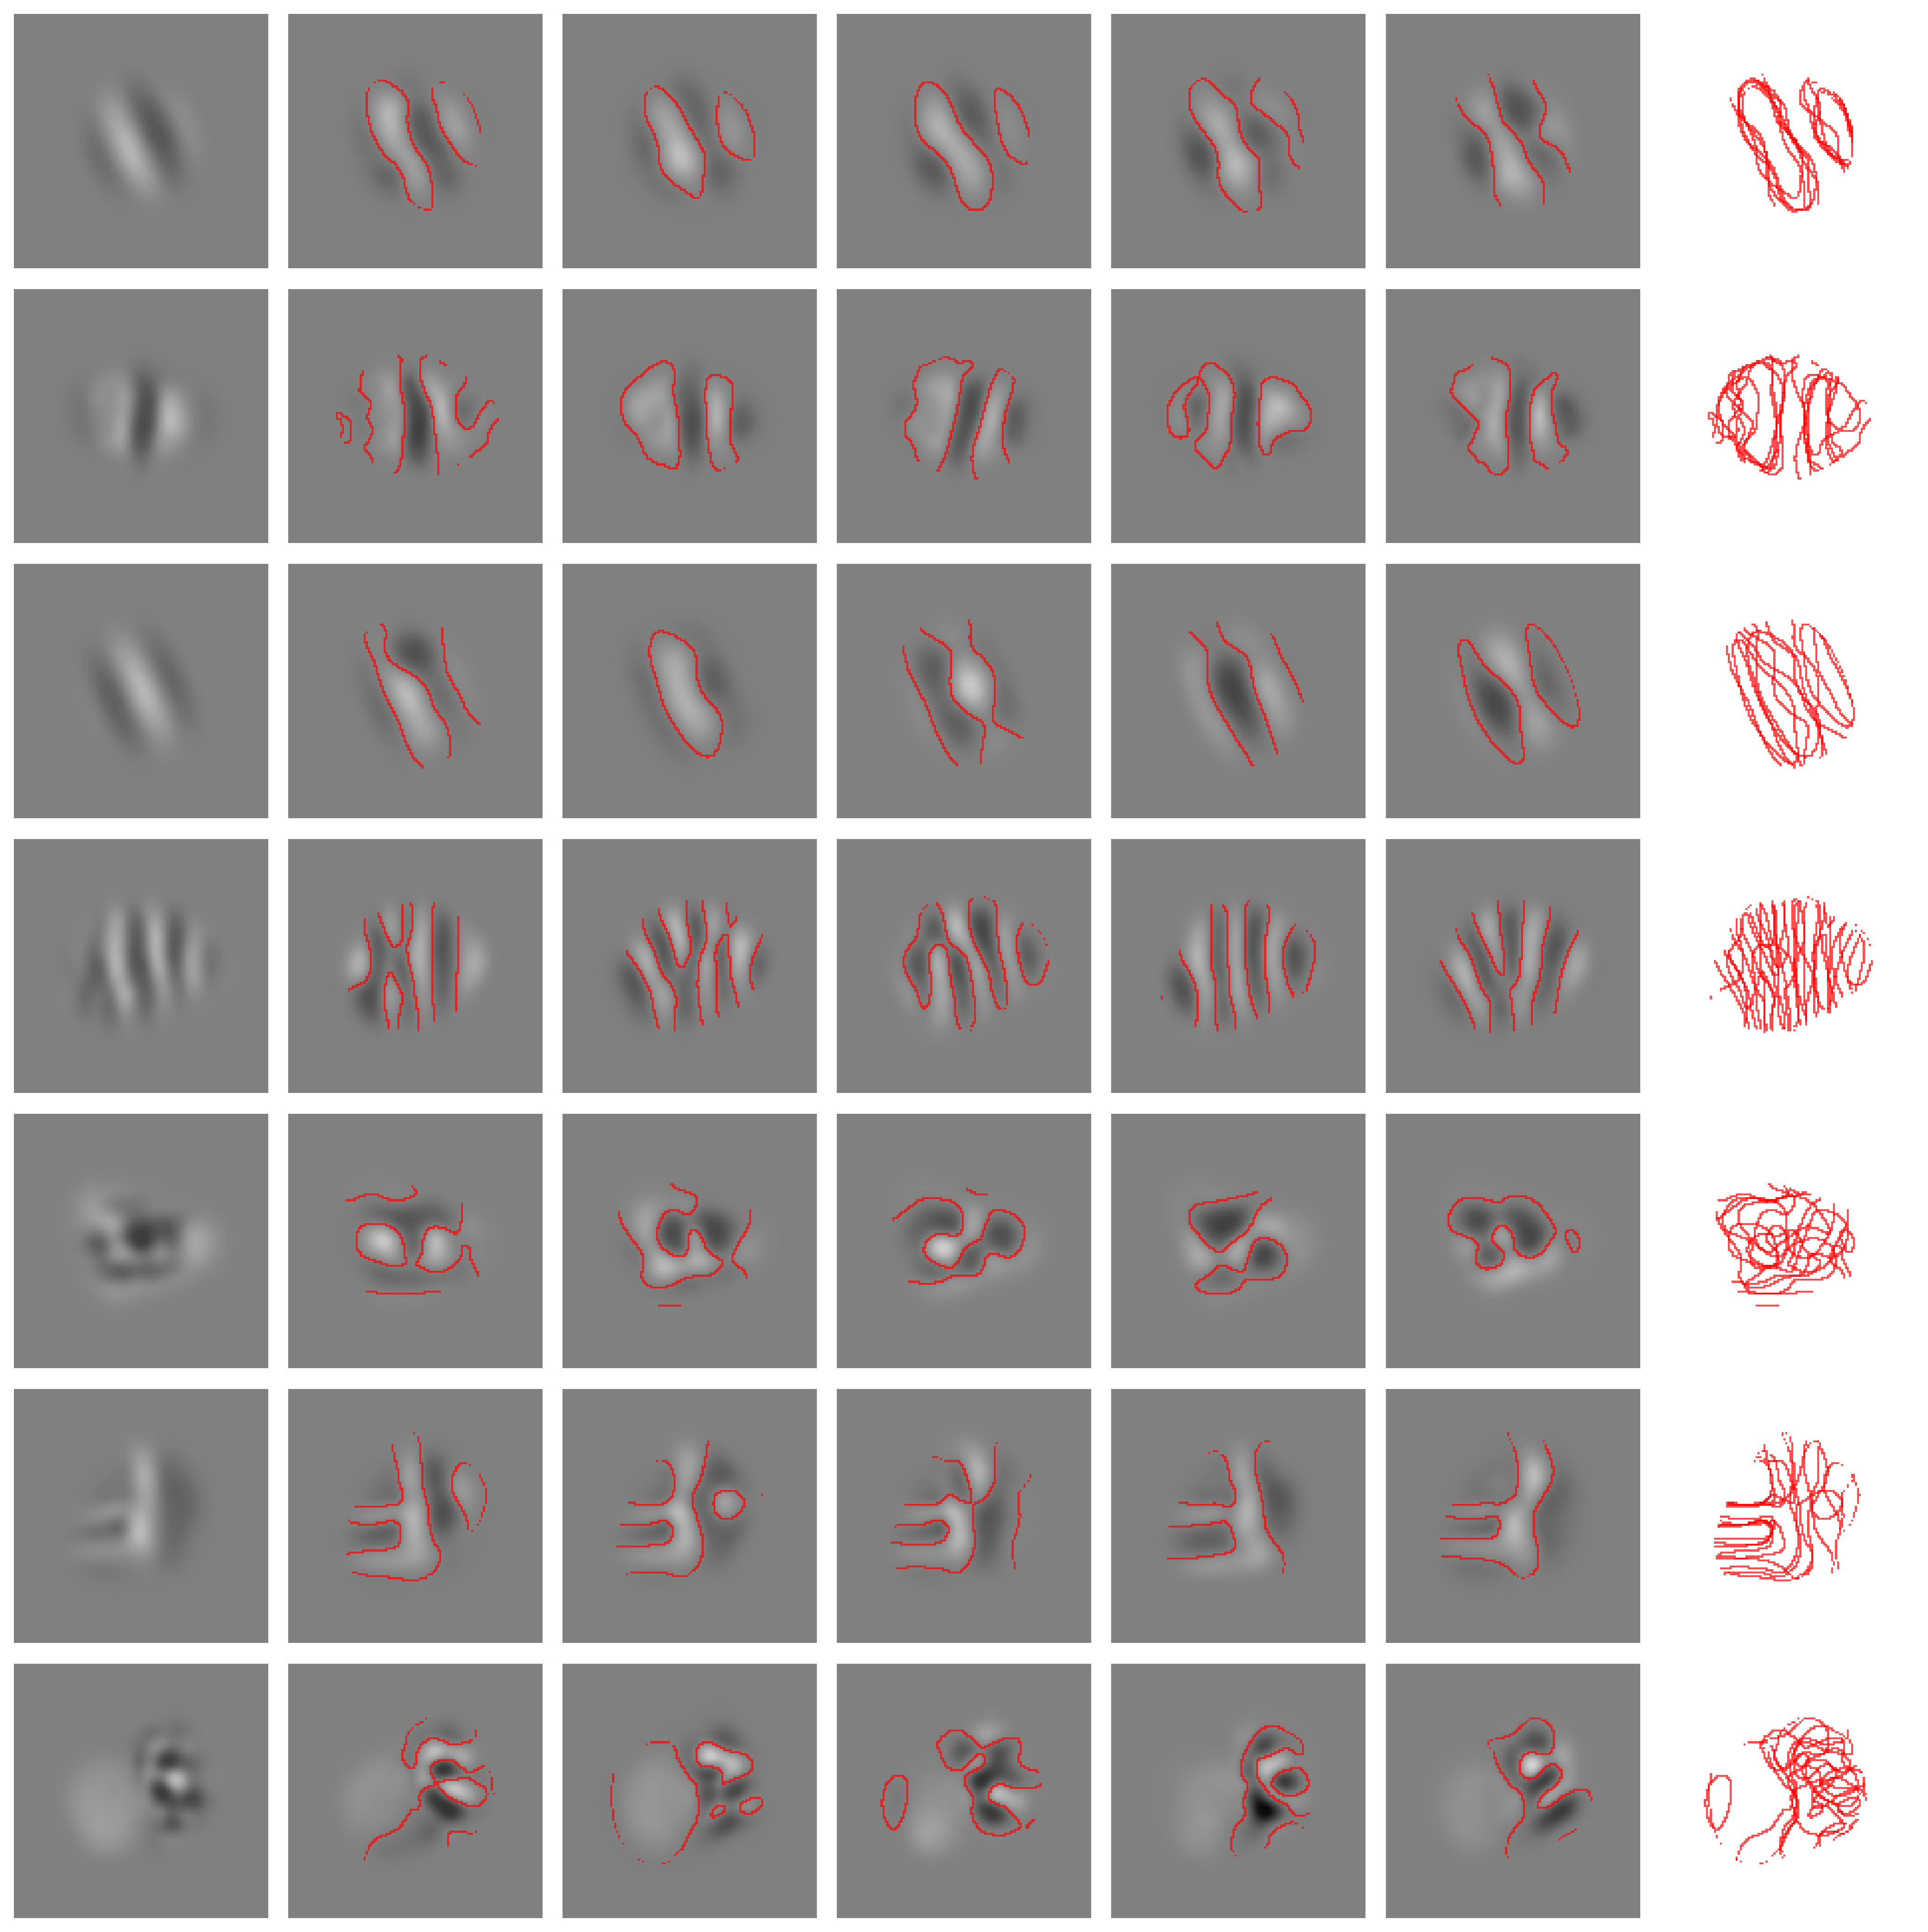

In [17]:
colors = [[255, 0, 0]] * n_images
mask_thresh = 0.3

fig, axes = plt.subplots(len(all_deis), n_images+2, figsize=((n_images+2)*2, len(all_deis)*2), dpi=300)
for i, (x, y, m, d, cross, mask) in enumerate(zip(all_xs, all_ys, all_meis, all_deis, crosses, all_masks)):
    # make upsampled binary mask
    mask = ndimage.zoom(mask.astype(np.float32), np.array([144, 256]) / mask.shape)
    mask = mask > mask_thresh
    
    # show MEI
    axes[i, 0].imshow(center_and_crop_image(m, x, y, (128, 128))[0], cmap='gray', vmin=0, vmax=255)
    
    # prepare zero-crossing in different colors on transparent background
    images = []
    for cro, color in zip(cross, colors):
        # make image a 4d RGBA array
        cro_copy = center_and_crop_image(cro.copy() * mask, x, y, (128, 128))[0]
        image = np.zeros(cro_copy.shape + (4,))
        for j in range(3):
            image[:, :, j] = color[j] / 255
        image[:, :, 3] = cro_copy
        images.append(image)
    
    # show DEI with zero-crossing
    for ax, im, im_cro in zip(axes[i, 1:-1], d, images):
        ax.imshow(center_and_crop_image(im, x, y, (128, 128))[0], cmap='gray', vmin=0, vmax=255)
        ax.imshow(im_cro, alpha=0.7)
    
    # overlay all DEI zero-crossings
    for im in images:
        axes[i, -1].imshow(im,alpha=0.7)
                       
for ax in axes.ravel():
    ax.axis('off')
    
fig.tight_layout()
fig.savefig('/src/notebooks/Official_figures/[Fig2_a]Example_stimuli_MEI_DEI_with_zero_crossing.pdf')

## 2b

In [21]:
# all v1 neurons
rest1 = 'group_id in (233, 237) and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 14 and threshold_params = 2'
rest2 = 'group_id in (239, 243, 271, 272, 275, 279, 284, 285, 329, 330, 336, 337) and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 17 and threshold_params = 2'
all_div = deis_schema.compute_diversity_index(deis_schema.DEIGoodRun & [rest1, rest2])

# closed loop neurons from experiments for more diverse neurons
rest = ['group_id in (233, 237, 239, 243, 272) and stim_type in ("dei_control_multi") and params_id !=4 and subtype in ("mei", "dei")',
       'group_id in (275, 279, 284) and stim_type in ("dei_texture_package") and params_id !=4 and subtype in ("mei", "dei")']
exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron - exclude)  
neuron_keys = (dj.U('group_id', 'neuron_id') & (DEIClosedLoopSummaryResults.Subtype & neuron_rel & rest)).fetch(as_dict=True)
rest1 = 'group_id in (233, 237) and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 14 and threshold_params = 2'
rest2 = 'group_id in (239, 243, 272, 275, 279, 284) and seed = 1009 and net_hash in ("8b6fe18fa651ebf452db0fbd77d05a01", "403a616c4761b733cb767a47a6d0e7da") and data_hash = "7572eed73113c993e7d1b92f83e270b4" and mei_params = 10 and mask_params = 3 and diverse_params = 17 and threshold_params = 2'
loop_div = deis_schema.compute_diversity_index(deis_schema.DEIGoodRun & [rest1, rest2] & neuron_keys)

# toy neurons
toy_rest = {'group_id': 6, 'mei_params': 1, 'mask_params':3, 'mask_stats_params': 2, 'diverse_params': 22, 'threshold_params': 2, 'texture_params': 20, 'score_params': 2}
sim = (toy_deis.DEINew & (toy_deis.DEINewGoodRun & toy_rest)).fetch('avg_sim', order_by='group_id, member_id')
toy_div = deis_schema.convert_score(- sim)

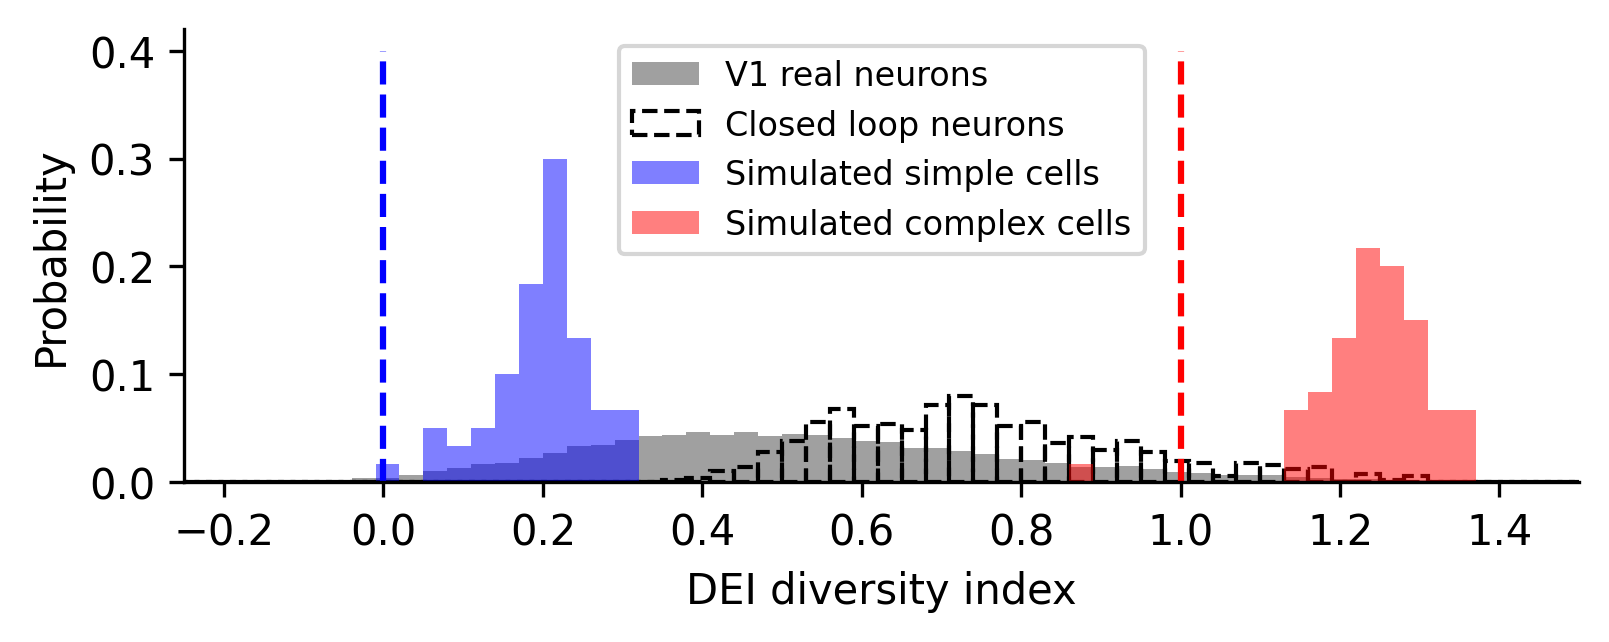

In [22]:
plt.figure(figsize=(6, 2), dpi=300)
min_val, max_val = np.concatenate([all_div, loop_div, toy_div]).min(), np.concatenate([all_div, loop_div, toy_div]).max()
ax = sns.histplot(all_div, color='gray', stat='probability', binwidth=0.03, binrange=[-0.25, 1.5], label='V1 real neurons', linewidth=0)
ax1 = sns.histplot(loop_div, color='k', stat='probability', binwidth=0.03, binrange=[-0.25, 1.5], label='Closed loop neurons', fill=False, linestyle='--', linewidth=1)
ax2 = sns.histplot(toy_div[60:], color='b', stat='probability', binwidth=0.03, binrange=[- 0.25, 1.5], label='Simulated simple cells', alpha=0.5, linewidth=0)
ax3 = sns.histplot(toy_div[:60], color='r', stat='probability', binwidth=0.03, binrange=[-0.25, 1.5], label='Simulated complex cells', alpha=0.5, linewidth=0)
plt.vlines(0, ymin=0, ymax=0.4, linestyles='dashed', color='b')
plt.vlines(1.0, ymin=0, ymax=0.4, linestyles='dashed', color='r')

plt.xlim([-0.25, 1.5])
plt.legend(fontsize=8, loc=0)
sns.despine()
plt.xlabel('DEI diversity index')
plt.savefig('/src/notebooks/Official_figures/[Fig2_b]DEI_diversity_histogram_with_toy_reference.pdf', transparent=True)


In [23]:
# complex
scipy.stats.ttest_ind(all_div, toy_div[:60], equal_var=False)

Ttest_indResult(statistic=-74.78008259545368, pvalue=1.15285536662352e-67)

In [24]:
# simple
scipy.stats.ttest_ind(all_div, toy_div[60:], equal_var=False)

Ttest_indResult(statistic=37.692129638491934, pvalue=3.132745010680098e-49)

In [25]:
cal_dof(all_div, toy_div[:60])

69.02100093096773

In [26]:
cal_dof(all_div, toy_div[60:])

72.42572236207393

## 2c

In [28]:
rest = 'group_id in (336, 337) and stim_type = "dei_multi_repeats"'
exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron - exclude)  
n_neurons = len(neuron_rel & (DEIClosedLoopSummaryResults.Subtype & rest))
groups, neurons, resps, subtypes = (DEIClosedLoopSummaryResults.Subtype & rest & neuron_rel).fetch('group_id', 'neuron_id', 'real_response', 'subtype', order_by='group_id, neuron_id, subtype')
resps = np.stack(resps).reshape(-1, 11, 20) # neurons * images * repeats


                 min       max    median        q1        q3       iqr  \
MEI          0.15264   6.76591  2.523868  1.022481  4.060354  3.037873   
$DEI_{1}$   0.576863   3.40193  1.241345  1.004681  2.061268  1.056587   
$DEI_{2}$   0.107513  7.632723  1.302737  0.944825   2.67552  1.730695   
$DEI_{3}$   0.068824  7.847307  2.023884  0.932581   3.67454  2.741959   
$DEI_{4}$        0.0  5.309988  1.805715  0.958722  3.106647  2.147925   
$DEI_{5}$        0.0  6.459958  1.284427  0.404634  2.118072  1.713438   
$DEI_{6}$   0.000735  4.990058  1.347905  0.694792   2.40462  1.709828   
$DEI_{7}$        0.0  5.777655  1.606539  0.777569  2.330307  1.552739   
$DEI_{8}$        0.0  2.514813  0.939997  0.248184  1.766238  1.518054   
$DEI_{9}$   0.036433  8.159282  1.984024  0.712421  3.765928  3.053507   
$DEI_{10}$  0.020668  7.104668  1.285593  0.686458  3.687321  3.000863   

           lower_whisker upper_whisker    center  \
MEI              0.15264       6.76591  2.779325   
$DEI_{1

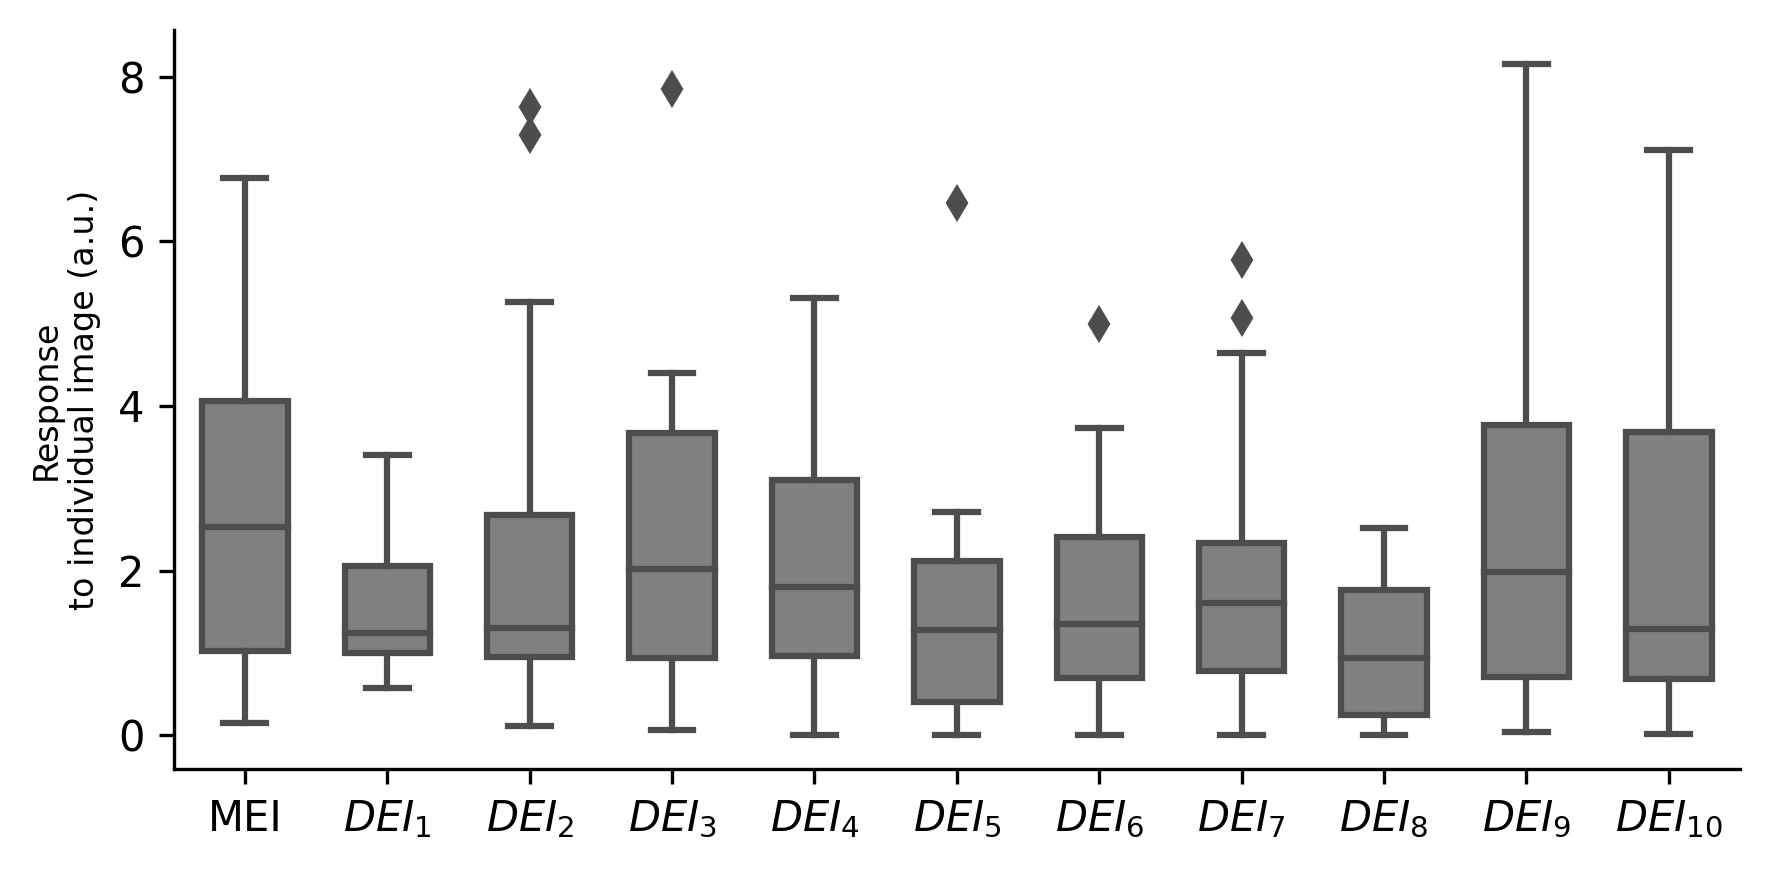

<Figure size 432x288 with 0 Axes>

In [41]:
idx = 90
y_labels = ['MEI'] + [f"$DEI_{{{i+1}}}$" for i in range(10)]

plt.figure(figsize=(6, 3), dpi=300)

# Construct x/y as in your original code
x = np.concatenate([[i] * 20 for i in range(11)])
y = np.concatenate([resps[idx, -1], resps[idx, :-1].ravel()])

# --- Compute Box-Whisker Statistics ---
stats = {}
for i, label in enumerate(y_labels):
    vals = y[x == i]
    if len(vals) == 0:
        continue
    q1 = np.percentile(vals, 25)
    q2 = np.percentile(vals, 50)
    q3 = np.percentile(vals, 75)
    iqr = q3 - q1
    lower_whisker = np.min(vals[vals >= q1 - 1.5 * iqr]) if np.any(vals >= q1 - 1.5 * iqr) else np.min(vals)
    upper_whisker = np.max(vals[vals <= q3 + 1.5 * iqr]) if np.any(vals <= q3 + 1.5 * iqr) else np.max(vals)
    stats[label] = {
        "min": np.min(vals),
        "max": np.max(vals),
        "median": q2,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_whisker": lower_whisker,
        "upper_whisker": upper_whisker,
        "center": np.mean(vals),
        "bounds": (lower_whisker, upper_whisker),
    }

# Optional: pretty-print summary table
import pandas as pd
df_stats = pd.DataFrame(stats).T
print(df_stats.round(3))

# --- Plot Boxplot ---
sns.boxplot(x=x, y=y, width=0.6, color='gray')
plt.ylabel('Response\nto individual image (a.u.)', fontsize=8)
plt.xticks(plt.gca().get_xticks(), y_labels)
sns.despine()
plt.tight_layout()
plt.show()

plt.savefig('/src/notebooks/Official_figures/[Fig2_c]Example_response_to_individual_DEIs_group{}_neuron{}_boxplot.pdf'.format(groups[idx], neurons[idx]), transparent=True)

## 2d

In [37]:
np.random.seed(419)
idxs = np.random.choice(np.arange(10), resps.shape[0], replace=True)
random_single_dei = resps.mean(-1)[:, :-1][np.arange(149), idxs]

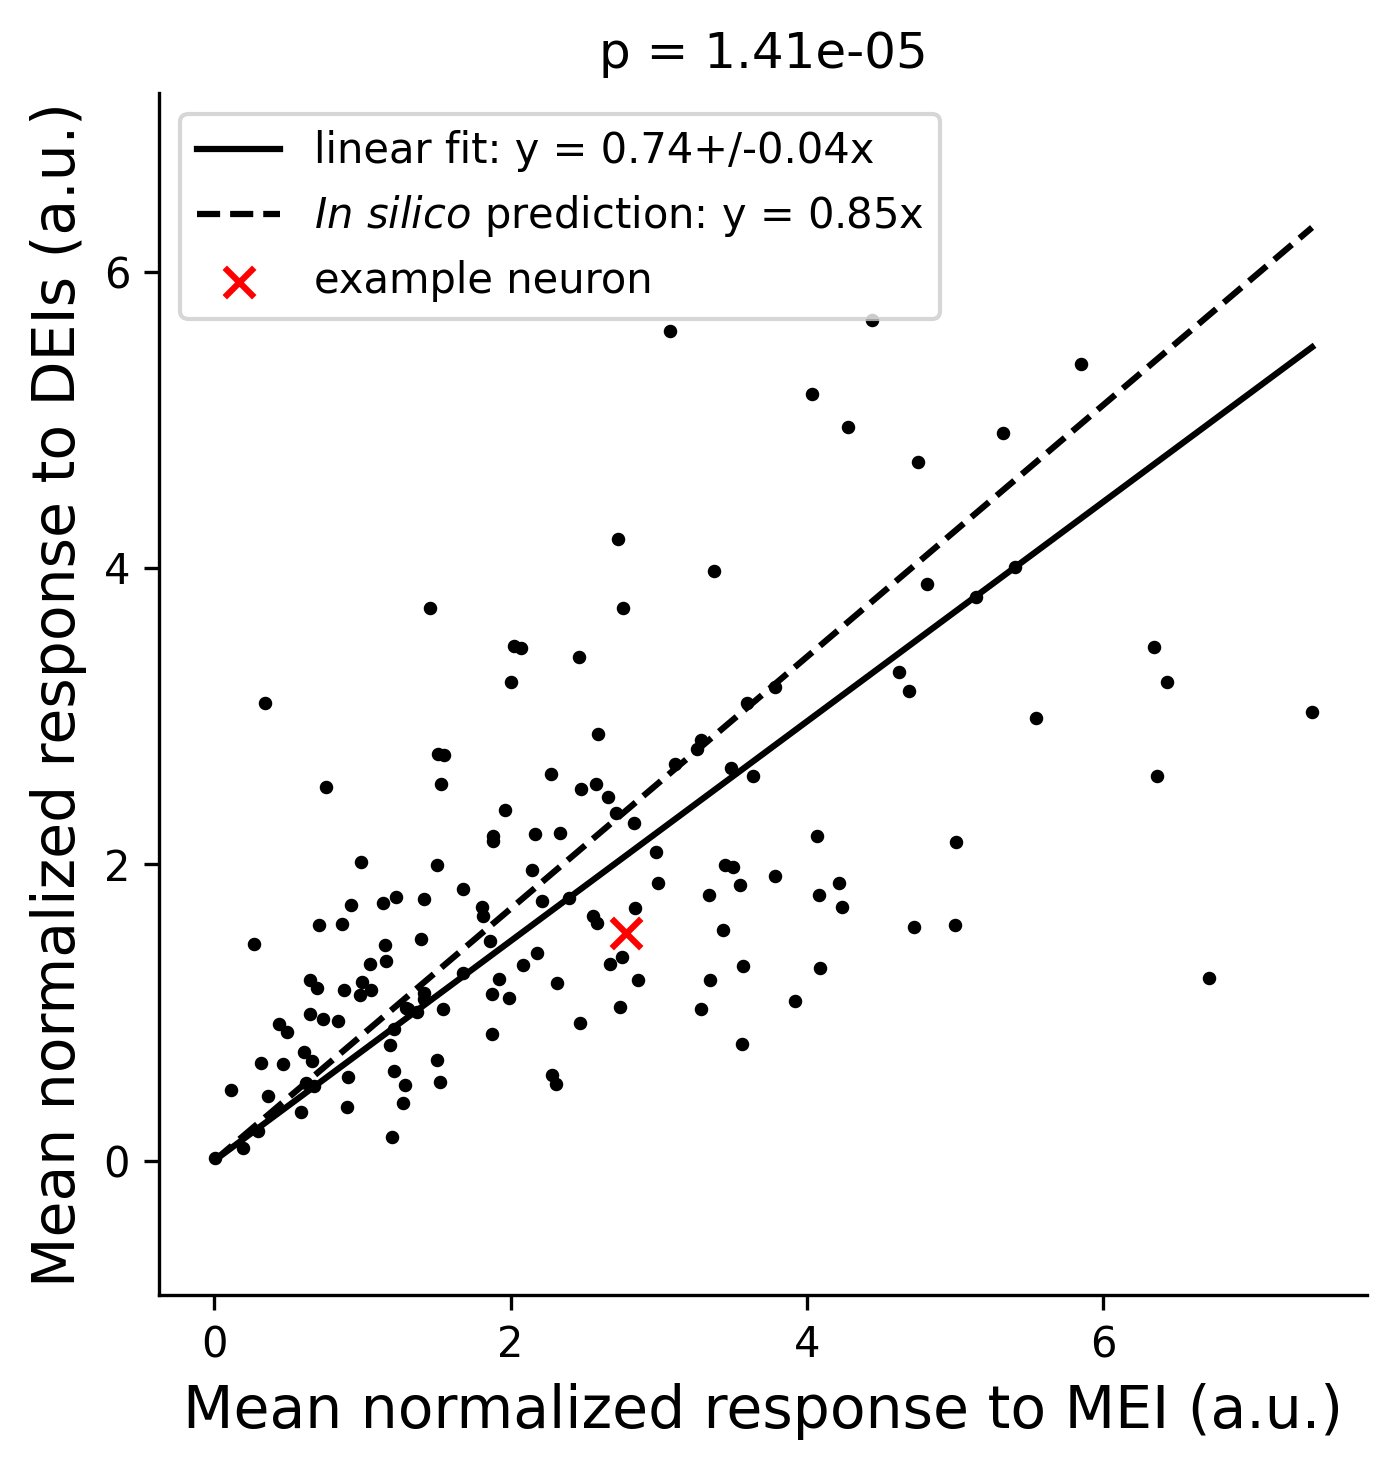

In [40]:
x = resps.mean(-1)[:, -1]
y = random_single_dei
example_idxs = np.array([90])
scatterplot_helper(x, y, 'Mean normalized response to MEI (a.u.)', 'Mean normalized response to DEIs (a.u.)', get_bound_from_data=True, plot_identity=False, exclude_idxs_for_scatter=example_idxs)
max_val = np.concatenate([x, y]).max()
plt.plot([0, max_val], [0, max_val*0.85], color='k', linestyle='dashed', label='$In\ silico$ prediction: y = 0.85x')
plt.scatter(x[example_idxs], y[example_idxs], color='r', s=50, marker='x', label='example neuron')
plt.legend(loc=2)
plt.xticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.yticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.axis('equal')
plt.savefig('/src/notebooks/Official_figures/[Fig2_d]Random_individual_DEI_from_each_neuron_against_MEI_responses.pdf', transparent=True)


In [34]:
all_coefs = []
for seed in range(10000):
    np.random.seed(seed)
    idxs = np.random.choice(np.arange(10), resps.shape[0], replace=True)
    random_single_dei = resps.mean(-1)[:, :-1][np.arange(149), idxs]
    x = resps.mean(-1)[:, -1]
    y = random_single_dei
    # non-robust fit
    from sklearn import linear_model
    x = x[:, np.newaxis]
    lr = linear_model.LinearRegression(fit_intercept=False)
    lr.fit(x, y)
    coef = lr.coef_.item()
    all_coefs.append(coef)

In [14]:
np.percentile(all_coefs, 2.5)

0.6496353726097904

In [15]:
np.percentile(all_coefs, 97.5)

0.7711163607786322

In [12]:
np.mean(all_coefs)

0.7087865930519096

In [13]:
np.std(all_coefs)

0.030990005711797036

In [39]:
get_stat(resps[:, -1]*0.85, resps[:, :-1][np.arange(149), idxs])

WilcoxonResult(statistic=4902.0, pvalue=0.1939135758361401)
DOF: 32.58
Prior correction: Different 29 19.46% Less 10 6.71%, Greater 19 12.75%
Post correction: Different 4 2.68% Less 1 0.67%, Greater 3 2.01%


## 2e

In [53]:
# pixel dei
dics1 = (dj.U('animal_id', 'session', 'scan_idx', 'group_id', 'params_id') & \
       (DEIClosedLoopSummaryResults.Neuron & 'stim_type in ("dei_control_multi") and params_id != 4 and animal_id not in (26872, 28120)')).fetch(as_dict=True, order_by='group_id')
dics2 = (dj.U('animal_id', 'session', 'scan_idx', 'group_id', 'params_id') & \
       (DEIClosedLoopSummaryResults.Neuron & 'stim_type in ("dei_texture_package") and animal_id in (27802, 27470, 27940)')).fetch(as_dict=True, order_by='group_id')
dics = list(dics1) + list(dics2)

# # population dei
# dics = (dj.U('animal_id', 'session', 'scan_idx', 'group_id', 'params_id') & \
#        (DEIClosedLoopSummaryResults.Neuron & 'stim_type = "dei_control_multi" and params_id = 4 and animal_id != 26872')).fetch(as_dict=True, order_by='group_id')

# # random neuron pixel dei
# dics = (dj.U('animal_id', 'session', 'scan_idx', 'group_id', 'params_id') & \
#        (DEIClosedLoopSummaryResults.Neuron & 'stim_type = "dei_texture_package" and params_id != 4 and animal_id in (28120, 29515, 29513)')).fetch(as_dict=True, order_by='group_id')


In [54]:
mei_key = dics[3] # group 239

single_mats, subtypes = (NewConfusionMatrix.Matrix() & mei_key & 'norm_method=3' & 'subtype not LIKE "oracle%%"').fetch('all_response', 'subtype', order_by='subtype')
n_neurons = 80
dei_mat = single_mats[-2].reshape(n_neurons, 20, n_neurons).mean(1)
mei_mat = single_mats[-1].mean(-1)

# delete bad matching neurons 
exclude_cols = get_exclude_neurons(manual_exclude_dic, mei_key=mei_key)
dei_mat = np.delete(np.delete(dei_mat, exclude_cols, 0), exclude_cols, 1)
mei_mat = np.delete(np.delete(mei_mat, exclude_cols, 0), exclude_cols, 1)

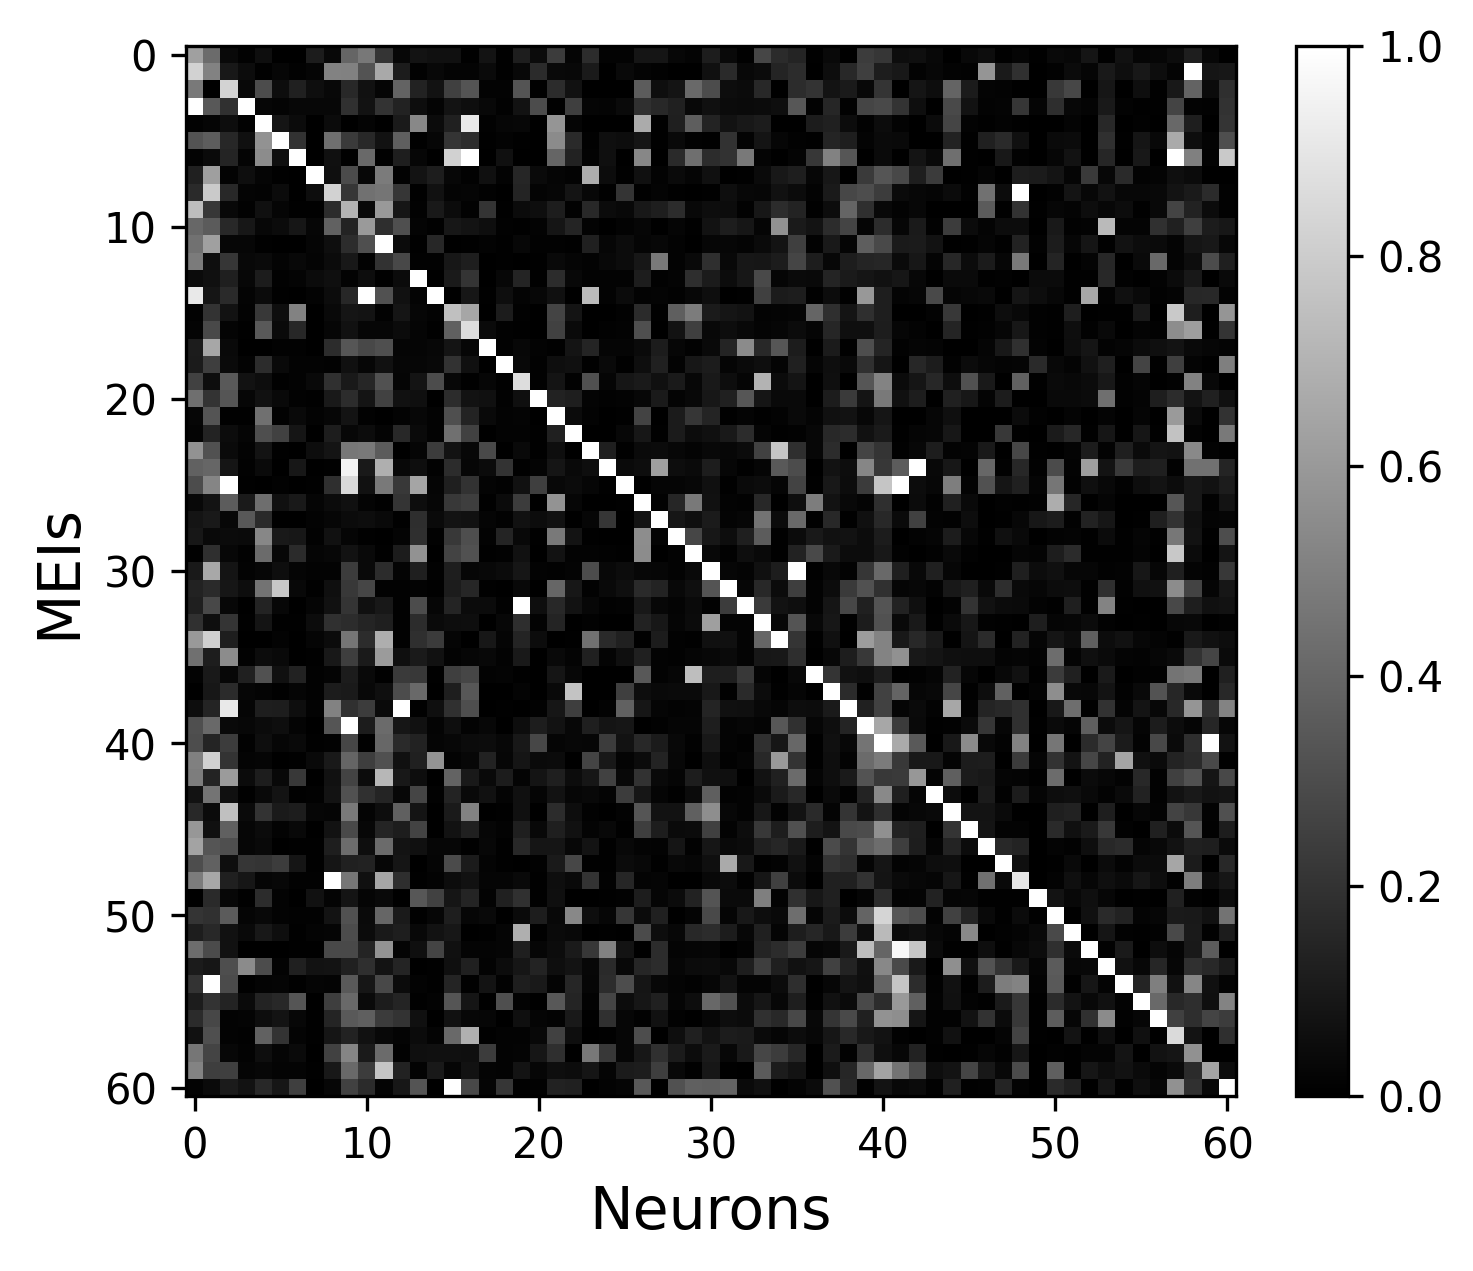

In [55]:
mat_type = 'MEIs'
fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
if mat_type == 'MEIs':
    im = ax.imshow(mei_mat / mei_mat.max(0), vmin=0, vmax=1, cmap='gray')
else:
    im = ax.imshow(dei_mat / dei_mat.max(0), vmin=0, vmax=1, cmap='gray')
ax.set_xlabel('Neurons', fontsize=14)
ax.set_ylabel(mat_type, fontsize=14)

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.2)
   
plt.colorbar(im, cax=cax)

plt.savefig('/src/notebooks/Official_figures/[Fig2_e]Confusion_matrix_{}.pdf'.format(mat_type), transparent=True)

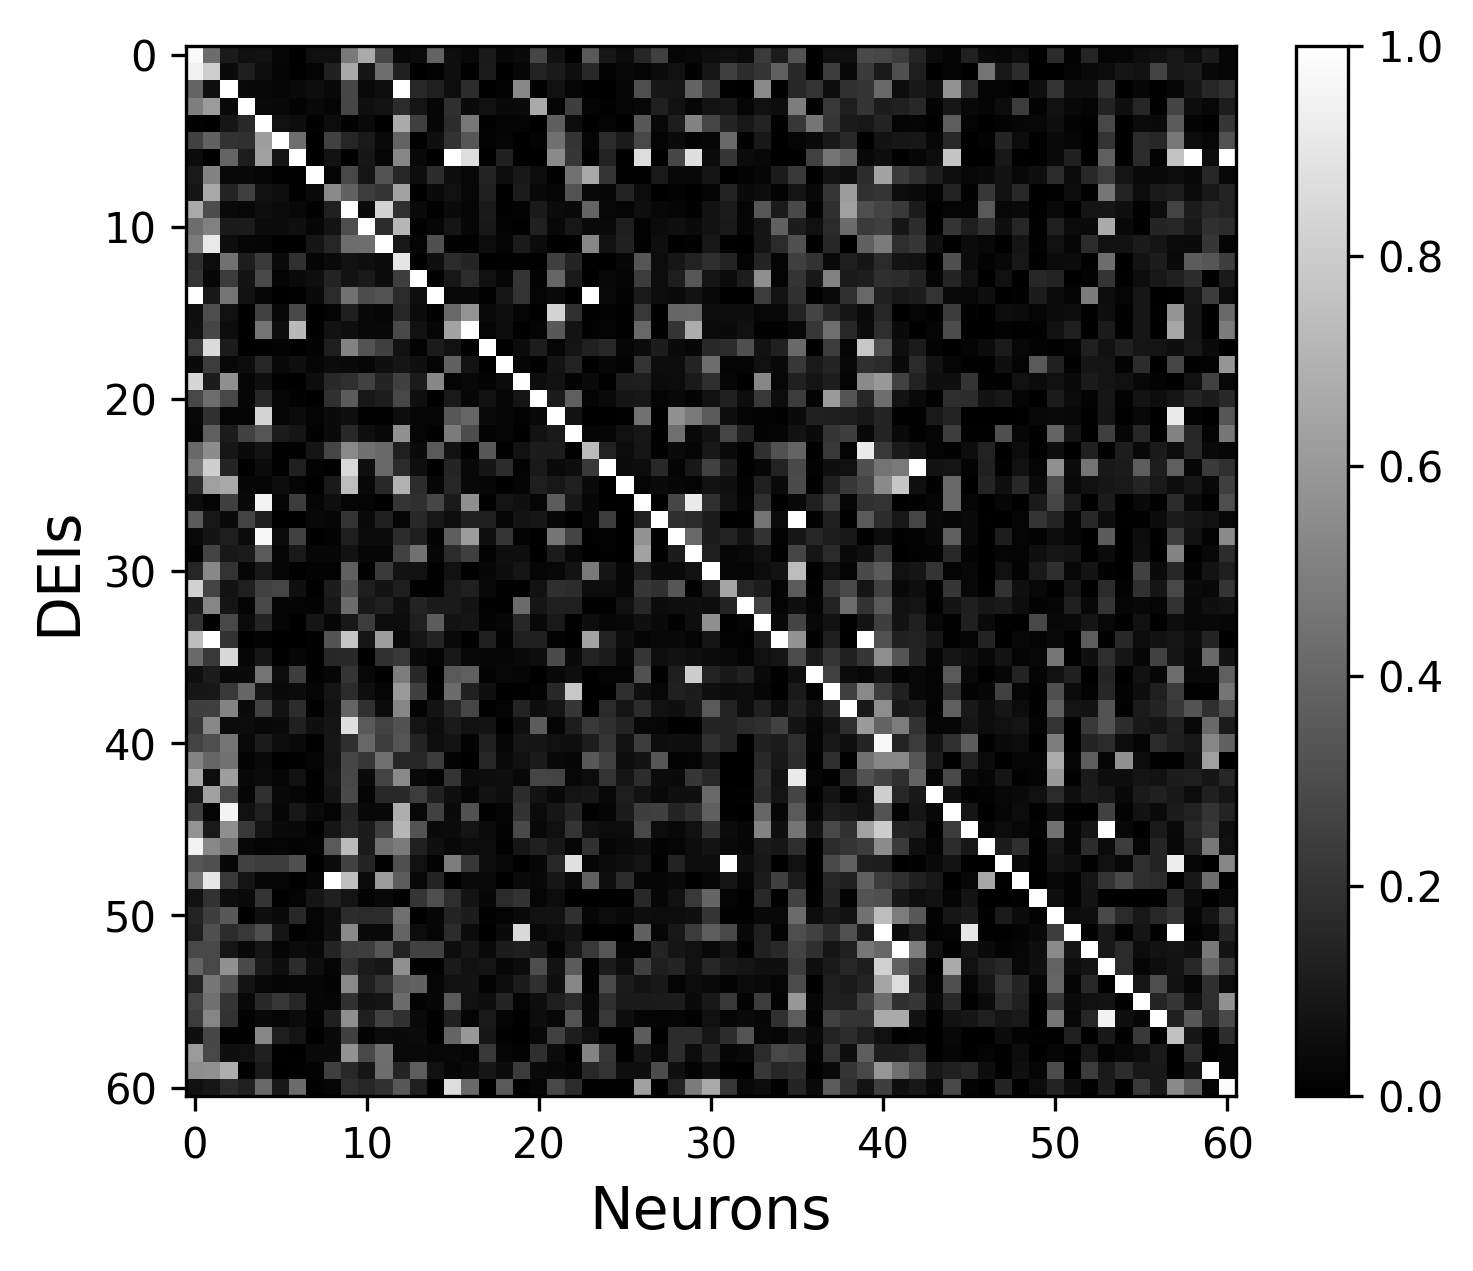

In [57]:
mat_type = 'DEIs'
fig, ax = plt.subplots(1, 1, figsize=(5, 5), dpi=300)
if mat_type == 'MEIs':
    im = ax.imshow(mei_mat / mei_mat.max(0), vmin=0, vmax=1, cmap='gray')
else:
    im = ax.imshow(dei_mat / dei_mat.max(0), vmin=0, vmax=1, cmap='gray')
ax.set_xlabel('Neurons', fontsize=14)
ax.set_ylabel(mat_type, fontsize=14)

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.2)
   
plt.colorbar(im, cax=cax)

plt.savefig('/src/notebooks/Official_figures/[Fig2_e]Confusion_matrix_{}.pdf'.format(mat_type), transparent=True)

## 2f

In [107]:
rest = ['animal_id in (26614, 26645, 26726, 26942, 27468) and stim_type in ("dei_control_multi") and params_id !=4',
        'animal_id in (27802, 27470, 27940) and stim_type in ("dei_texture_package") and params_id !=4']
exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron - exclude)

dics = (DEIClosedLoopSummaryResults & rest & neuron_rel).fetch(as_dict=True, order_by='animal_id, session, scan_idx')

n_repeats = 20
all_neurons = []
real_resps, model_resps = [], []
for mei_key in dics:
    mei_key = (closed_loop.ClosedLoopScan & mei_key).fetch1()
    stim_type = mei_key['stim_type']
    group = (data_schemas.StaticMultiDatasetGroupAssignment * (closed_loop.ClosedLoopScan & {'loop_group': mei_key['loop_group']} & 'mei_source = 1') & 'spike_method = 5 and preproc_id in (5, 9)').fetch('group_id')[0]
    mei_table = (StimSubtype() & dict(stim_type=mei_key['stim_type'], subtype="mei")).get_stim_tables()[1][0]
    model_key = (mei_table & {'group_id': group}).fetch('group_id', 'net_hash', 'data_hash', 'readout_key', as_dict=True, limit=1)[0]
    src_key = (data_schemas.StaticMultiDatasetGroupAssignment & model_key).fetch1()
    model_key.update(src_key)
    single_mats, subtypes = (NewConfusionMatrix.Matrix() & mei_key & 'norm_method=3' & {'stim_type': stim_type} & 'subtype in ("dei", "mei")').fetch('all_response', 'subtype', order_by='subtype')
    # neurons = (stimulus.StaticImage.Image * (Scan.Frame() * mei_table & mei_key)).fetch('neuron_id', order_by='neuron_id') # source scan neurons
    include_neurons = (neuron_rel & mei_key).fetch('neuron_id', order_by='group_id, neuron_id')
    all_neurons.append(include_neurons)

    for mat, subtype in zip(single_mats[-2:], subtypes[-2:]):
        subtype_rest = dict(subtype = subtype)
        images, neurons = get_stimulus(mei_key, model_key, subtype_rest)
        include_idxs = np.array([np.where(neurons == n)[0].item() for n in include_neurons])
        all_models, readout_key, mean_eyepos = load_model(model_key)
        r = get_model_resps(images, neurons, all_models, readout_key, mean_eyepos)
    
        if 'mei' in subtype:
            real_resps.append(mat.mean(-1).T[include_idxs].astype(np.float32)) # neurons * images
            model_resps.append(r.T.reshape(len(neurons), len(neurons), -1).mean(-1)[include_idxs].astype(np.float32)) # neurons * images
        elif 'dei' in subtype: 
            n_neurons = mat.shape[-2]
            real_resps.append(mat.reshape(n_neurons, n_repeats, n_neurons).mean(1).T[include_idxs].astype(np.float32)) # neurons * images
            model_resps.append(r.T.reshape(len(neurons), len(neurons), -1).mean(-1)[include_idxs].astype(np.float32)) # neurons * images


12-11-2025:04:57:22 INFO     configs.py           242:	 Ignoring input arguments: "net_hash", "core_hash", "ro_hash", "shift_hash", "mod_hash", "train_hash", "data_hash", "group_id", "seed", "train_type", "schedule", "max_epoch", "loss_type", "avg_loss"when creating datasets
12-11-2025:04:57:22 INFO     configs.py           222:	 Loading None dataset with tier=train
12-11-2025:04:57:22 INFO     data_schemas.py     1318:	 Fetching data for {'group_id': 233, 'description': 'Inserted from PipelineManagement'}
12-11-2025:04:57:22 INFO     data_schemas.py     1328:	 Data will be (images,behavior,pupil_center,responses)
12-11-2025:04:57:22 INFO     data_schemas.py     1331:	 Loading dataset group233-26614-1-16-5 --> /dj-stor01/cache/static26614-1-16-preproc5-spikemethod5.h5
12-11-2025:04:57:22 INFO     configs.py           227:	 Adding stats_source "all" to dataset
12-11-2025:04:57:22 INFO     configs.py           231:	 Using statistics source all
12-11-2025:04:57:22 INFO     configs.py     

In [108]:
group_idx = 1
mei_key = dics[group_idx]
mei_key = (closed_loop.ClosedLoopScan & mei_key).fetch1()
stim_type = mei_key['stim_type']
group = (data_schemas.StaticMultiDatasetGroupAssignment * (closed_loop.ClosedLoopScan & {'loop_group': mei_key['loop_group']} & 'mei_source = 1') & 'spike_method = 5 and preproc_id in (5, 9)').fetch('group_id')[0]
mei_table = (StimSubtype() & dict(stim_type=mei_key['stim_type'], subtype="mei")).get_stim_tables()[1][0]
model_key = (mei_table & {'group_id': group}).fetch('group_id', 'net_hash', 'data_hash', 'readout_key', as_dict=True, limit=1)[0]
src_key = (data_schemas.StaticMultiDatasetGroupAssignment & model_key).fetch1()
model_key.update(src_key)
single_mats, subtypes = (NewConfusionMatrix.Matrix() & mei_key & 'norm_method=3' & {'stim_type': stim_type} & 'subtype not LIKE "oracle%%"').fetch('all_response', 'subtype', order_by='subtype')
# neurons = (stimulus.StaticImage.Image * (Scan.Frame() * mei_table & mei_key)).fetch('neuron_id', order_by='neuron_id') # source scan neurons
include_neurons = (neuron_rel & mei_key).fetch('neuron_id', order_by='group_id, neuron_id')
subtype_rest = dict(subtype = subtypes[-1])
images, neurons = get_stimulus(mei_key, model_key, subtype_rest)
ingroup_neuron_idx = np.where(neurons == 6444)[0].item()


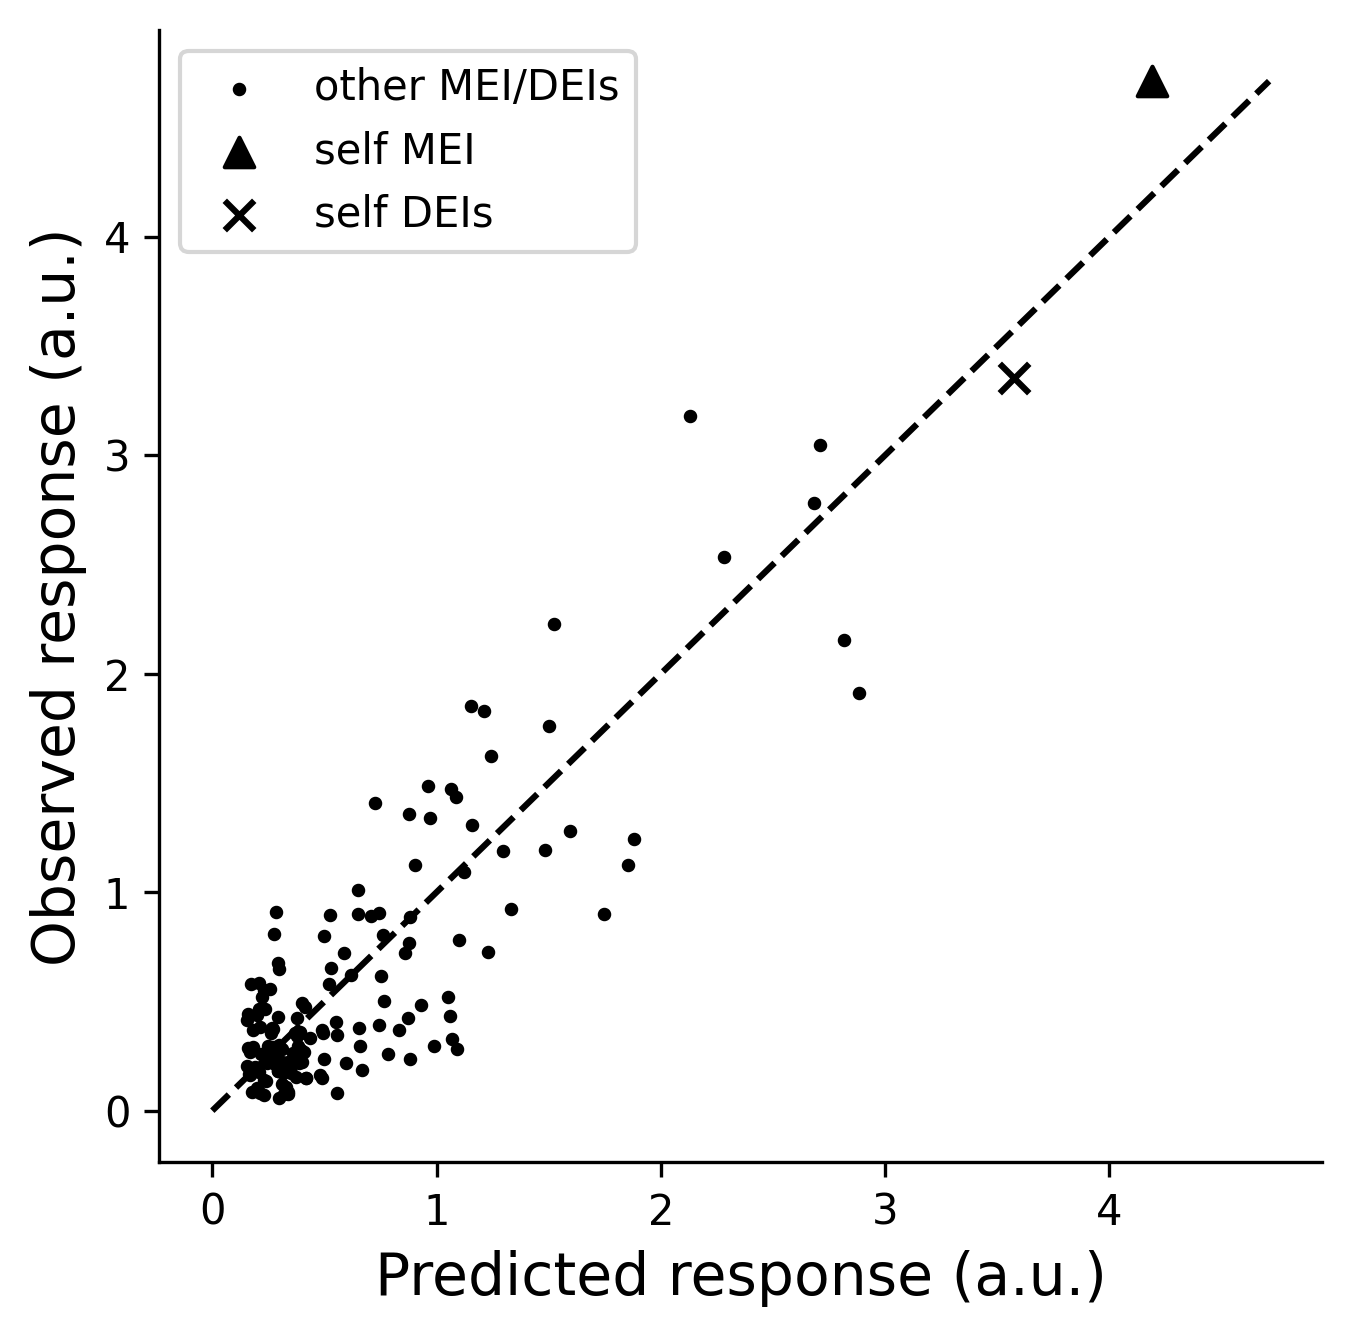

In [109]:
# plot single example neuron
plt.figure(figsize=(5, 5), dpi=300)
group_idx = 1
idx = np.where(all_neurons[group_idx] == 6444)[0].item()
max_val = np.concatenate([model_resps[2*group_idx+1][idx, :], real_resps[2*group_idx+1][idx, :]]).max()
plt.scatter(model_resps[2*group_idx+1][idx, :ingroup_neuron_idx], real_resps[2*group_idx+1][idx, :ingroup_neuron_idx], s=5, c='k', label='other MEI/DEIs')
plt.scatter(model_resps[2*group_idx+1][idx, ingroup_neuron_idx+1:], real_resps[2*group_idx+1][idx, ingroup_neuron_idx+1:], s=5, c='k')
plt.scatter(model_resps[2*group_idx][idx, :ingroup_neuron_idx], real_resps[2*group_idx][idx, :ingroup_neuron_idx], s=5, c='k')
plt.scatter(model_resps[2*group_idx][idx, ingroup_neuron_idx+1:], real_resps[2*group_idx][idx, ingroup_neuron_idx+1:], s=5, c='k')

plt.scatter(model_resps[2*group_idx+1][idx, ingroup_neuron_idx], real_resps[2*group_idx+1][idx, ingroup_neuron_idx], s=50, c='k', marker='^', label='self MEI')
plt.scatter(model_resps[2*group_idx][idx, ingroup_neuron_idx], real_resps[2*group_idx][idx, ingroup_neuron_idx], s=50, c='k', marker='x', label='self DEIs')
plt.plot([0, max_val], [0, max_val], c='k', linestyle='--')
sns.despine()
plt.legend()
plt.xlabel('Predicted response (a.u.)', fontsize=14)
plt.ylabel('Observed response (a.u.)', fontsize=14)
plt.savefig('/src/notebooks/Official_figures/[Fig2_f]Example_single_neuron_observed_vs_predicted.pdf', transparent=True)

## 2g

In [110]:
from scipy.stats import pearsonr
mei_correlations, dei_correlations = [], []
for i in range(len(dics)):
    mei_correlations.extend([pearsonr(m, r)[0] for m, r in zip(model_resps[2*i+1], real_resps[2*i+1])])
    dei_correlations.extend([pearsonr(m, r)[0] for m, r in zip(model_resps[2*i], real_resps[2*i])])
correlations = np.concatenate([np.array(mei_correlations)[None], np.array(dei_correlations)[None]])

In [111]:
np.hstack(all_neurons).shape

(500,)

In [112]:
correlations.mean(1)

array([0.74364886, 0.74517353])

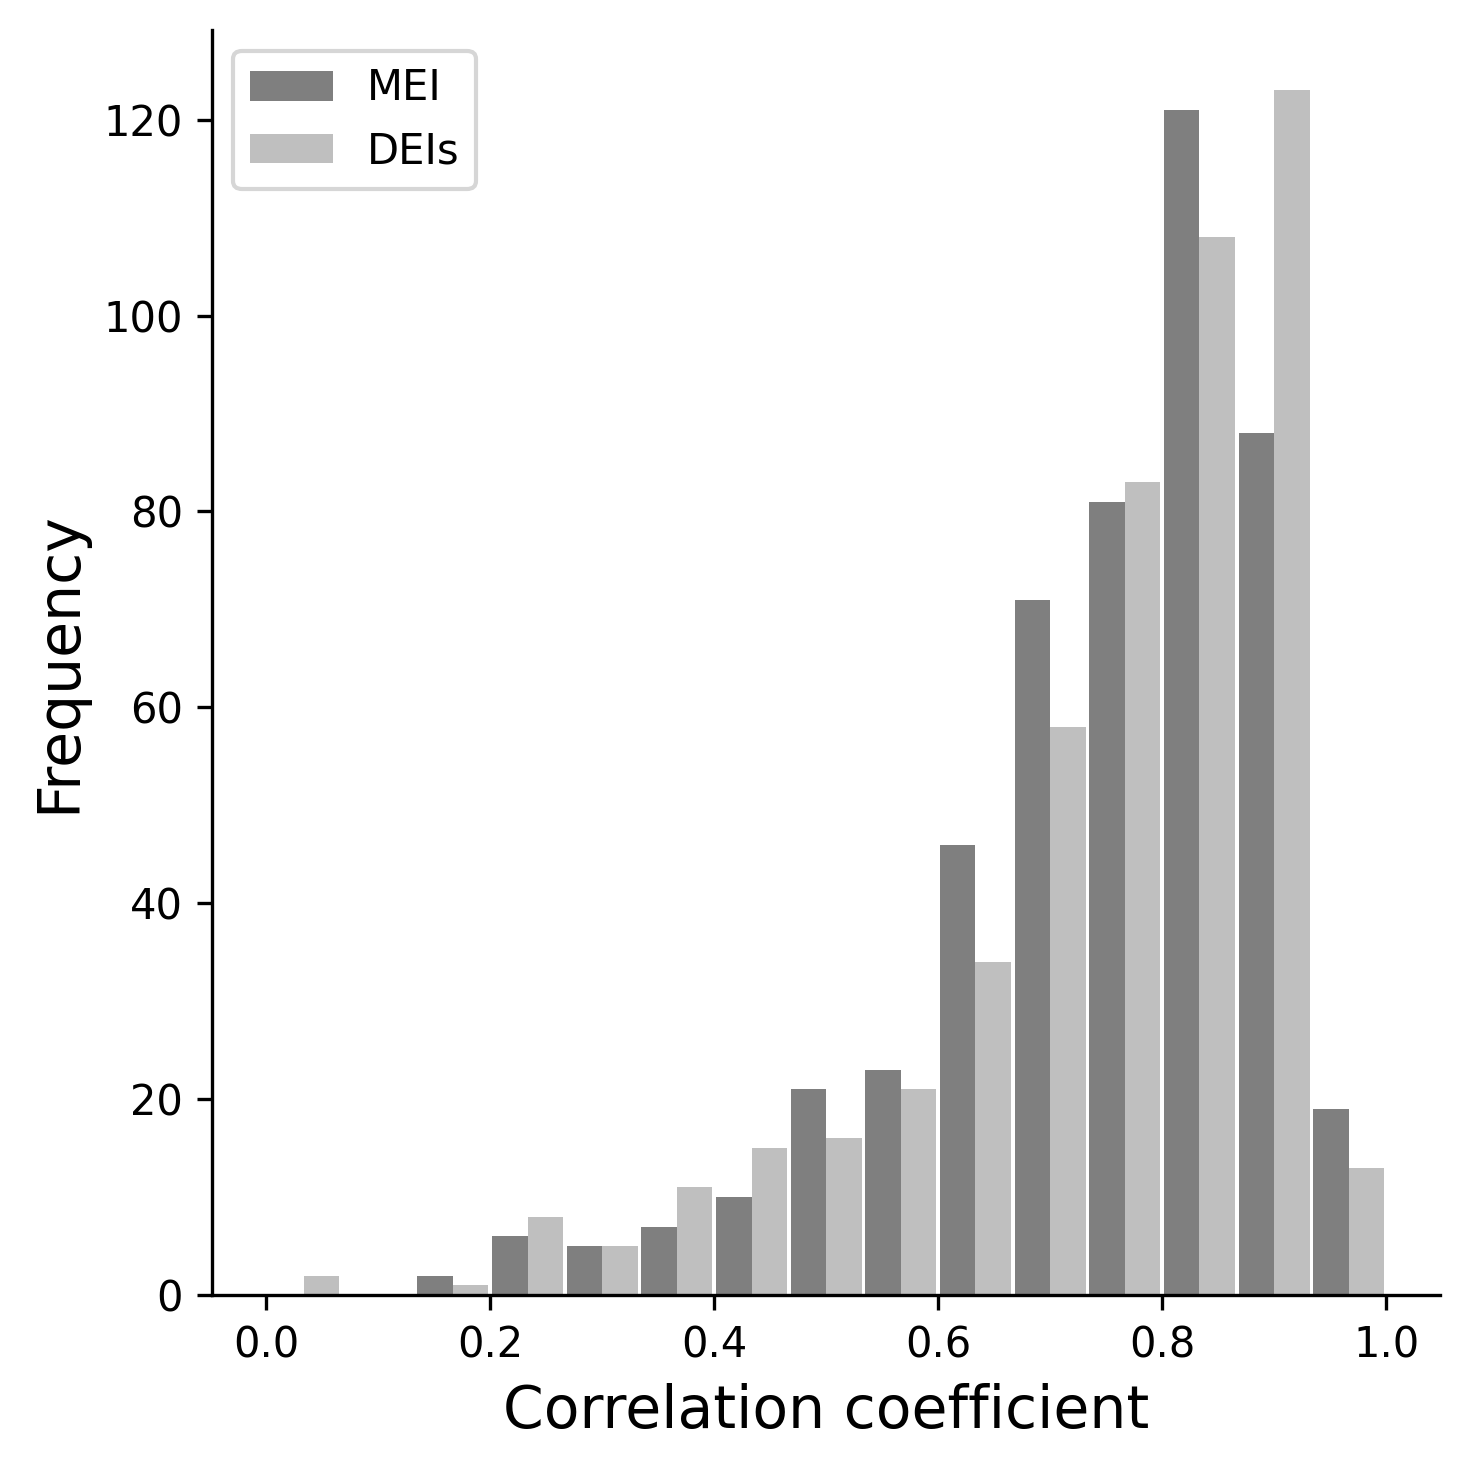

In [113]:
plt.figure(figsize=(5, 5), dpi=300)
plt.hist(correlations.T, bins=15, range=[0, 1], color=['k', 'gray'], rwidth=0.95, alpha=0.5, label=['MEI', 'DEIs'])
plt.legend()
plt.xlabel('Correlation coefficient', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
sns.despine()
plt.tight_layout()
plt.savefig('/src/notebooks/Official_figures/[Fig2_g]Correlation_coefficient_histogram.pdf', transparent=True)

## 2h

In [103]:
n_repeats = 20
n_subtypes = 2
rest = ['group_id in (233, 237, 239, 243, 272) and stim_type in ("dei_control_multi") and params_id !=4 and subtype in ("mei", "dei")',
       'group_id in (275, 279, 284) and stim_type in ("dei_texture_package") and params_id !=4 and subtype in ("mei", "dei")']
exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron) - exclude

n_neurons = len(neuron_rel & (DEIClosedLoopSummaryResults.Subtype & rest))
real, model, subtypes, dists, corrs = (DEIClosedLoopSummaryResults.Subtype * neuron_rel & rest).fetch('real_response', 'model_response', 'subtype', 'matched_distance', 'matched_corr', order_by='group_id, neuron_id, subtype')
real = np.stack(real).reshape(n_neurons, n_subtypes, 20)
model = model.reshape(n_neurons, n_subtypes)
subtypes = np.stack(subtypes).reshape(n_neurons, n_subtypes)
dists = dists[::n_subtypes]
corrs = corrs[::n_subtypes]

all_diags = real.mean(-1).T
all_std_diags = real.std(-1, ddof=1).T

dei_mean, mei_mean = all_diags
dei_std, mei_std = all_std_diags
x_mean = mei_mean
x_std = mei_std

In [104]:
get_stat(real[:, -1]*0.85, real[:, -2])

WilcoxonResult(statistic=51360.0, pvalue=0.0004919432792615783)
DOF: 34.06
Prior correction: Different 48 9.60% Less 14 2.80%, Greater 34 6.80%
Post correction: Different 6 1.20% Less 0 0.00%, Greater 6 1.20%


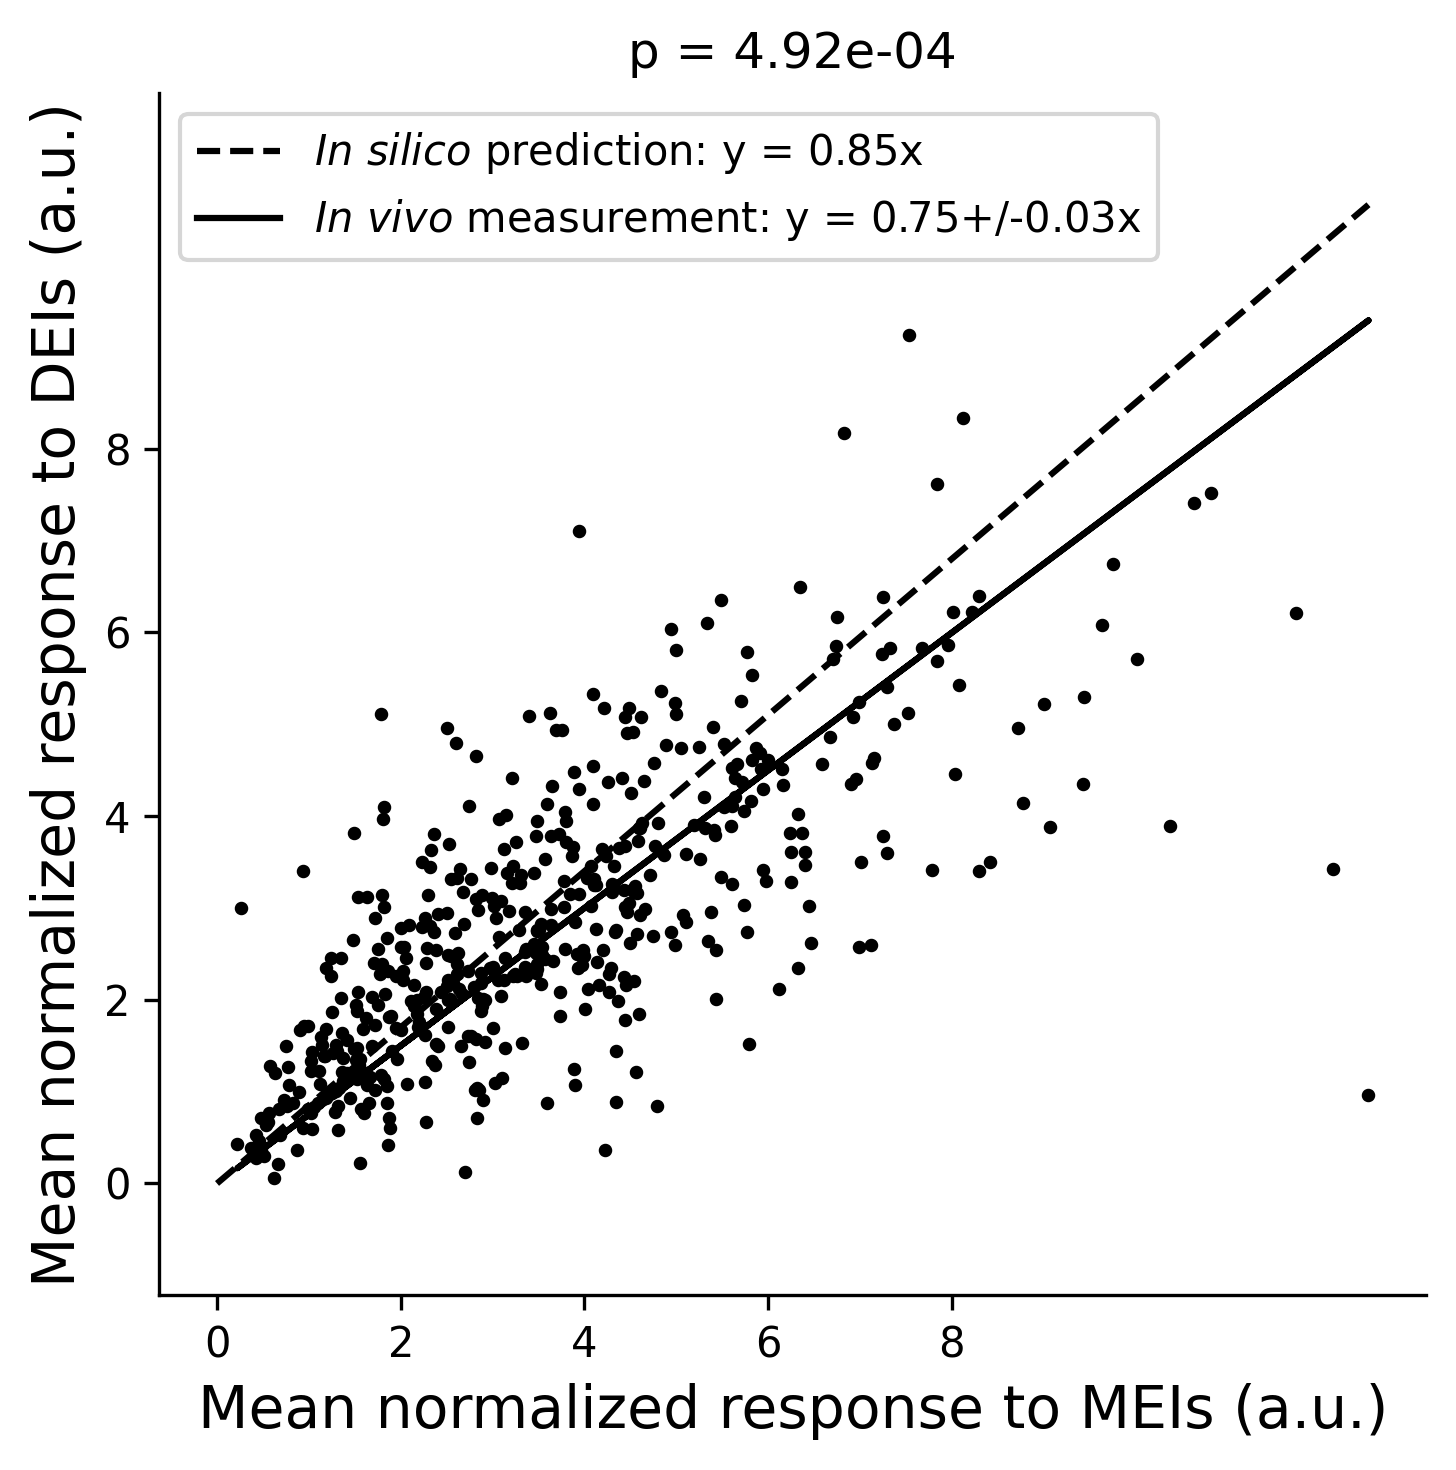

In [106]:
plt.figure(figsize=(5, 5), dpi=300)

ps = np.array([scipy.stats.ttest_ind_from_stats(m1*0.85,s1*0.85,n_repeats,m2,s2,n_repeats, equal_var=False)[1] for m1,s1,m2,s2 in zip(x_mean, x_std, dei_mean, dei_std)])
p_wc = scipy.stats.wilcoxon(x_mean*0.85, dei_mean)[1]
plt.scatter(x_mean[ps>0.05], dei_mean[ps>0.05], color='k', s=5, marker='o')
plt.scatter(x_mean[ps<=0.05], dei_mean[ps<=0.05], color='k', s=5, marker='o')

max_val = all_diags.max()
plt.plot([0, max_val], [0, max_val*0.85], color='k', linestyle='dashed', label='$In\ silico$ prediction: y = 0.85x')

# Linear fit 
from sklearn import linear_model
x = x_mean[:, np.newaxis]
# robust fit
coefs = []
for i in range(1000):
    ransac = linear_model.RANSACRegressor(base_estimator=linear_model.LinearRegression(fit_intercept=False), max_trials=1000)
    ransac.fit(x, dei_mean)
    coefs.append(ransac.estimator_.coef_.item())
coef = np.mean(coefs) #median?
std_coef = np.std(coefs)
plt.plot(x_mean, coef*x_mean, color='k', label='$In\ vivo$ measurement: y = {:.2f}+/-{:.2f}x'.format(coef, std_coef))

plt.xlabel('Mean normalized response to MEIs (a.u.)', fontsize=14)
plt.ylabel('Mean normalized response to DEIs (a.u.)', fontsize=14)

plt.title('p = {}'.format(np.format_float_scientific(p_wc, precision=2)))
plt.xticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.yticks([0, 2, 4, 6, 8], [0, 2, 4, 6, 8])
plt.legend(loc=2)
sns.despine()
plt.tight_layout()
plt.axis('equal')
plt.savefig('/src/notebooks/Official_figures/[Fig2_h]Scatter_of_MEI_vs_DEI_responses.pdf', transparent=True)

## 2i

In [42]:
rest = 'group_id in (336, 337) and stim_type = "dei_multi_repeats"'
exclude = get_exclude_neurons(manual_exclude_dic, exclude_type='scatter')
neuron_rel = (DEIClosedLoopSummaryResults.Neuron - exclude)  
n_neurons = len(neuron_rel & (DEIClosedLoopSummaryResults.Subtype & rest))
mei_keys = (DEIClosedLoopSummaryResults & (neuron_rel & (DEIClosedLoopSummaryResults.Subtype & rest))).fetch(as_dict=True, order_by='stim_type')

In [43]:
hash_keys_1_all, hash_keys_2_all = [], []
all_good_idxs = []
for mei_key in mei_keys:
    frame_table = stimulus.StaticImage.MaskedDEI * stimulus.Frame * NewConfusionMatrix.Frame & mei_key
    groups, neurons, resps, subtypes = (DEIClosedLoopSummaryResults.Subtype & rest & neuron_rel & mei_key).fetch('group_id', 'neuron_id', 'real_response', 'subtype', order_by='group_id, neuron_id, subtype')
    neurons = neurons[::11]
    subtypes = np.stack(subtypes).reshape(-1, 11)[:, :10]
    resps = np.stack(resps).reshape(-1, 11, 20) # neurons * images * repeats
    # get single trial responses 
    mei_trial_resps = resps[:, -1]
    dei_trial_resps = resps[:, :-1]

    for mei_r, dei_r, neuron, subtype in zip(mei_trial_resps, dei_trial_resps, neurons, subtypes):
        pair_idxs = np.random.choice(np.arange(10), 2, replace=False)
        idx1, idx2 = pair_idxs
        hash_keys_1_all.append((frame_table & {'neuron_id': neuron, 'subtype': subtype[idx1]}).fetch('animal_id', 'session', 'scan_idx', 'group_id', 'neuron_id', 'condition_hash', as_dict=True)[0])
        hash_keys_2_all.append((frame_table & {'neuron_id': neuron, 'subtype': subtype[idx2]}).fetch('animal_id', 'session', 'scan_idx', 'group_id', 'neuron_id', 'condition_hash', as_dict=True)[0])

In [44]:
all_pop1_all, all_pop2_all = [], []
for hash1, hash2 in tqdm(zip(hash_keys_1_all, hash_keys_2_all)):
    # Compute real neuron population response similarity of the DEI pair
    responses = (InputResponse.ResponseBlock & hash1).fetch1('responses')
    rows1 = (InputResponse.Input() & hash1).fetch('row_id')
    rows2 = (InputResponse.Input() & hash2).fetch('row_id')
    pop1 = responses[rows1]
    pop2 = responses[rows2] 
    all_pop1_all.append(pop1)
    all_pop2_all.append(pop2)

149it [11:10,  4.50s/it]


In [45]:
bet_accs, within_accs = [], []
for dei1_resps, dei2_resps in zip(all_pop1_all, all_pop2_all):
    between_accuracy,within_accuracy = sanity_check(dei1_resps[None], dei2_resps[None], cv=5)
    bet_accs.append(between_accuracy)
    within_accs.append(within_accuracy)


In [114]:
ttest_1samp(np.concatenate(bet_accs),0.5)

Ttest_1sampResult(statistic=29.203897873025316, pvalue=2.6412940137543407e-63)

In [116]:
ttest_ind(np.concatenate(bet_accs), np.concatenate(within_accs), equal_var=False)

Ttest_indResult(statistic=19.78723802718058, pvalue=4.2540271002669795e-56)

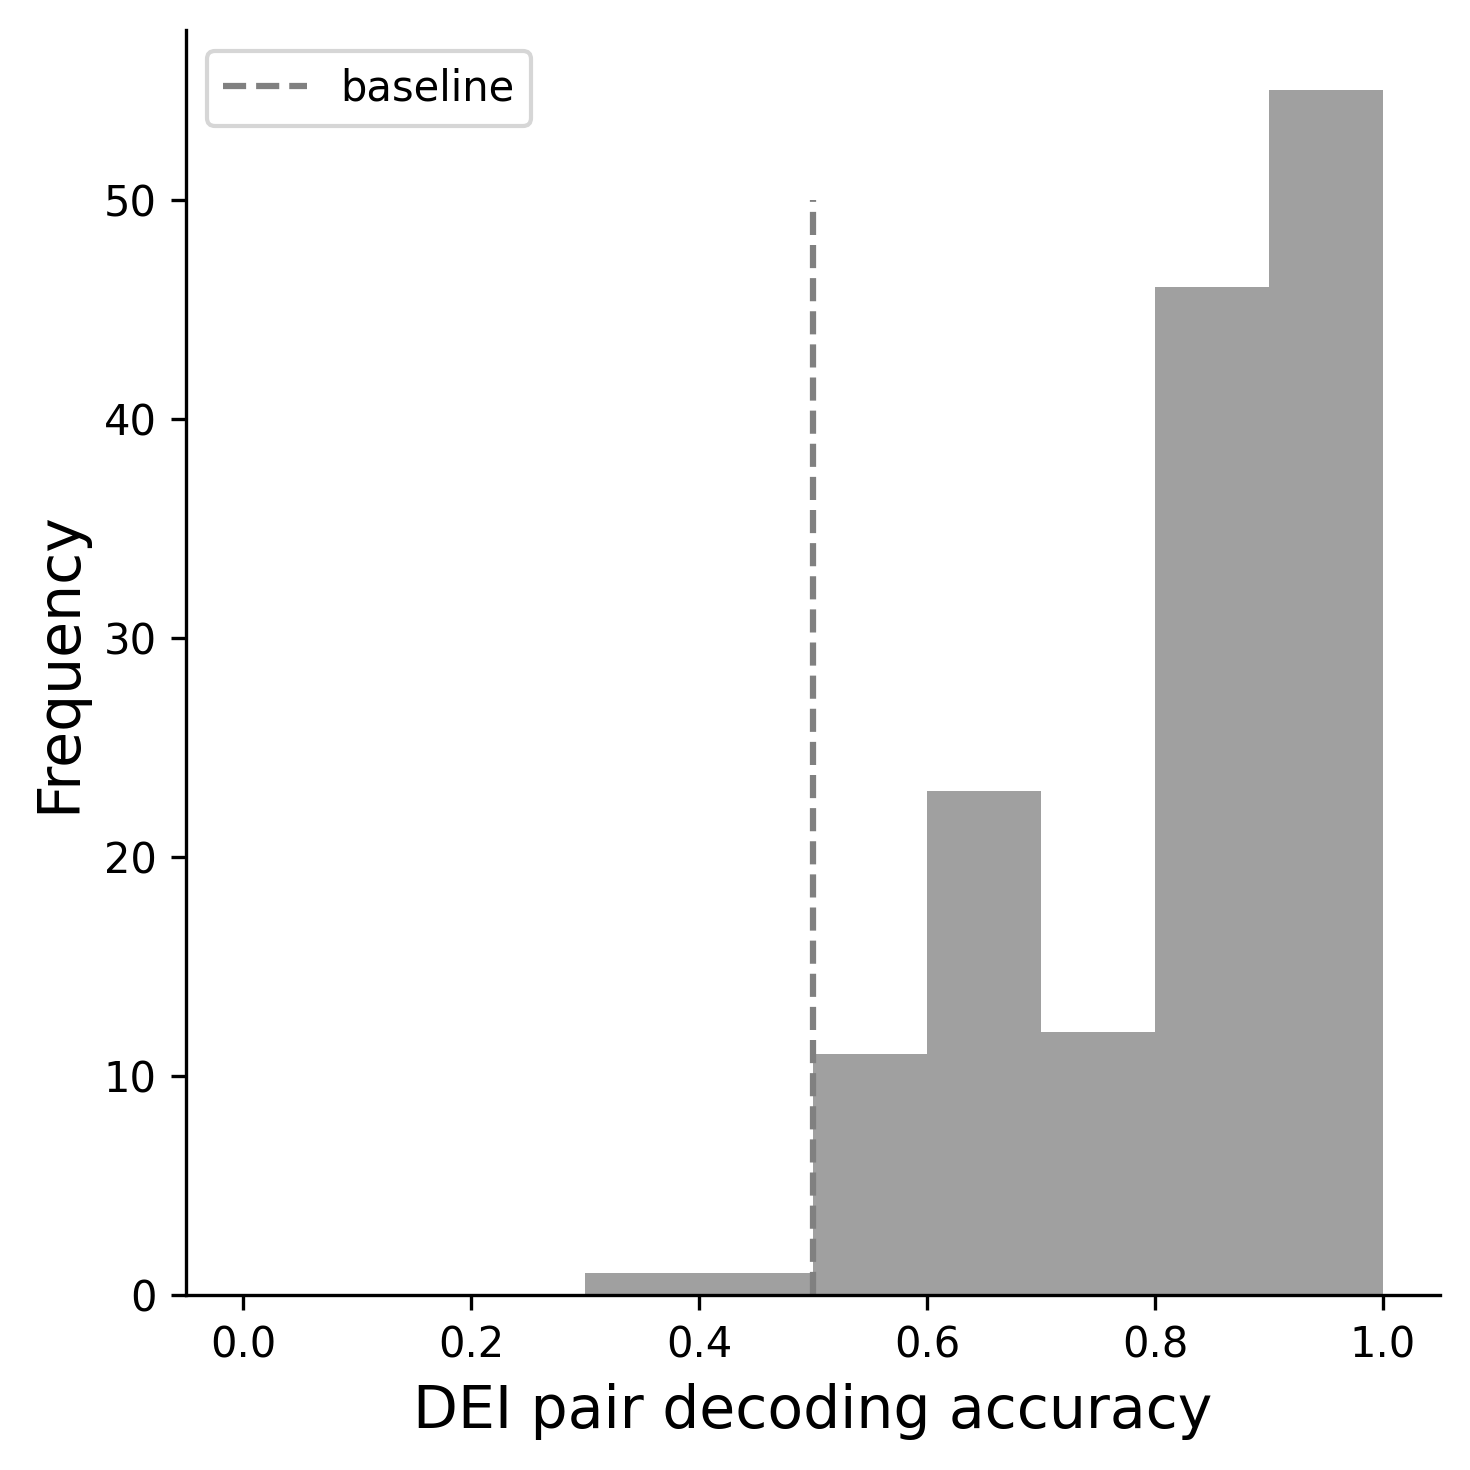

In [52]:
plt.figure(figsize=(5, 5), dpi=300)

sns.histplot(np.concatenate(bet_accs), bins=10, binrange=[0, 1], stat='count', color='gray', linewidth=0)
plt.vlines(0.5, ymin=0, ymax=50, linestyle='--', color='gray', label='baseline') # same image decoding baseline
# plt.vlines(np.concatenate(within_accs).mean(), ymin=0, ymax=175, linestyle='--', color='gray', label='baseline') # same image decoding baseline
sns.despine()
plt.legend()
plt.ylabel('Frequency', fontsize=14)
plt.xlabel('DEI pair decoding accuracy', fontsize=14)
plt.tight_layout()
plt.savefig('/src/notebooks/Official_figures/[Fig2_i]random_DEI_pair_decoding_histogram.pdf', transparent=True)